In [1]:
pip install langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 12.0 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from kaggle_secrets import UserSecretsClient

load_dotenv()

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GOOGLE_API_KEY")

llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash",google_api_key=secret_value_0)

class translate_substate(TypedDict):
    input_text:str
    translated_text:str

def substate_node(state:translate_substate)->translate_substate:
    prompt=f"Translate the follwing text into hindi and do not add extra thing keep it as it is {state["input_text"]}"
    response=llm.invoke(prompt).content
    return {"translated_text":response}

substate=StateGraph(translate_substate)
substate.add_node("substate_node",substate_node)
substate.add_edge(START,"substate_node")
substate.add_edge("substate_node",END)

subgraph=substate.compile()


class parent_state(TypedDict):
    topic:str
    generate_text:str
    hindi_text:str


def generate_text_node(state:parent_state)->parent_state:
    prompt=f"Generate a brief answer on the question {state["topic"]}"
    generate_text=llm.invoke(prompt).content
    return {"generate_text":generate_text}

def translate_text_node(state:parent_state):
    generate_text=state["generate_text"]
    x=subgraph.invoke({"input_text":generate_text})
    hindi_text=x["translated_text"]
    return {"hindi_text":hindi_text}

states=StateGraph(parent_state)
states.add_node("generate_text_node",generate_text_node)
states.add_node("translate_text_node",translate_text_node)

states.add_edge(START,"generate_text_node")
states.add_edge("generate_text_node","translate_text_node")
states.add_edge("translate_text_node",END)

graph=states.compile()

initial_state={
    "topic":"What is Artificial Intelligence?"
}


result=graph.invoke(initial_state)
print(result["hindi_text"])

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


कृत्रिम बुद्धिमत्ता (एआई) कंप्यूटर विज्ञान का एक क्षेत्र है जिसका उद्देश्य मशीनों को ऐसे कार्य करने में सक्षम करना है जिनके लिए आमतौर पर मानवीय बुद्धिमत्ता की आवश्यकता होती है। इसमें सीखना, तर्क करना, समस्या-समाधान, बोध और भाषा को समझना शामिल है।


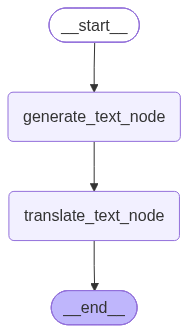

In [3]:
graph

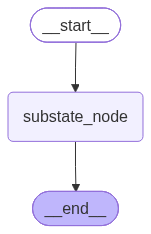

In [4]:
subgraph